In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Life-Expectancy-Data-Updated (1).csv')

In [4]:
#creamos la columna binaria correcta
df['Developed'] = (df['Economy_status_Developed'] == 1).astype(int)
df = df.drop(columns=['Economy_status_Developed'])
df = df.drop(columns=['Economy_status_Developing'])

In [21]:
df = df.dropna(subset=['GDP_per_capita'])

En los ultimos 15 anios, el PBI per capita de los paises desarrollados de america crecio, en porcentaje, mayormente que los paises subdesarrollados de america

In [51]:
desarrollados = df[df['Developed'] == 1]
subdesarrollados = df[df['Developed'] == 0]

In [52]:
des_2000 = desarrollados[desarrollados['Year'] == 2000][['Country', 'GDP_per_capita']]
des_2014 = desarrollados[desarrollados['Year'] == 2014][['Country', 'GDP_per_capita']]


In [53]:
subdes_2000 = subdesarrollados[subdesarrollados['Year'] == 2000][['Country', 'GDP_per_capita']]
subdes_2014 = subdesarrollados[subdesarrollados['Year'] == 2014][['Country', 'GDP_per_capita']]

In [54]:
subdesarrollados = subdes_2000.merge(

    subdes_2014,
    on='Country',
    suffixes=('_2000', '_2014')
)

subdesarrollados['percentage_inc'] = (
    (subdesarrollados['GDP_per_capita_2014'] - subdesarrollados['GDP_per_capita_2000'])
    / subdesarrollados['GDP_per_capita_2000']
) * 100

subdesarrollados

,Country,GDP_per_capita_2000,GDP_per_capita_2014,percentage_inc
0,Afghanistan,148,565,281.756757
1,Solomon Islands,1939,2195,13.202682
2,"Congo, Dem. Rep.",351,481,37.037037
3,Honduras,1790,2256,26.033520
4,Togo,506,554,9.486166
...,...,...,...,...
137,Myanmar,310,1168,276.774194
138,Argentina,10731,13568,26.437424
139,Lao PDR,936,2025,116.346154
140,Belarus,2617,6213,137.409247


In [55]:
desarrollados = des_2000.merge(

    des_2014,
    on='Country',
    suffixes=('_2000', '_2014')
)

desarrollados['percentage_inc'] = (
    (desarrollados['GDP_per_capita_2014'] - desarrollados['GDP_per_capita_2000'])
    / desarrollados['GDP_per_capita_2000']
) * 100

desarrollados

,Country,GDP_per_capita_2000,GDP_per_capita_2014,percentage_inc
0,Hungary,8971,12237,36.406198
1,Ireland,41623,50010,20.149917
2,France,33597,36379,8.280501
3,United States,48746,55675,14.214500
4,Italy,32351,29980,-7.328985
5,Cyprus,22382,22514,0.589760
6,Estonia,9960,17097,71.656627
7,Slovak Republic,8915,15547,74.391475
8,Japan,31431,34387,9.404728
9,Luxembourg,92528,105584,14.110323


<h3> Box-Plot

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

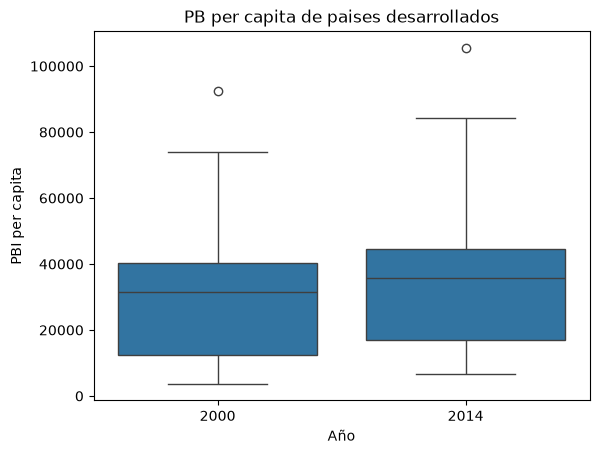

In [57]:
datos_box = desarrollados[['GDP_per_capita_2000', 'GDP_per_capita_2014']].melt(var_name='Year', value_name='Infant_deaths')
sns.boxplot(
    x='Year',
    y='Infant_deaths',
    data=datos_box,
    notch=False
)

plt.title("PB per capita de paises desarrollados")
plt.xlabel("Año")
plt.ylabel("PBI per capita")
plt.xticks(
    ticks=[0, 1],
    labels=["2000", "2014"]
)

plt.show()

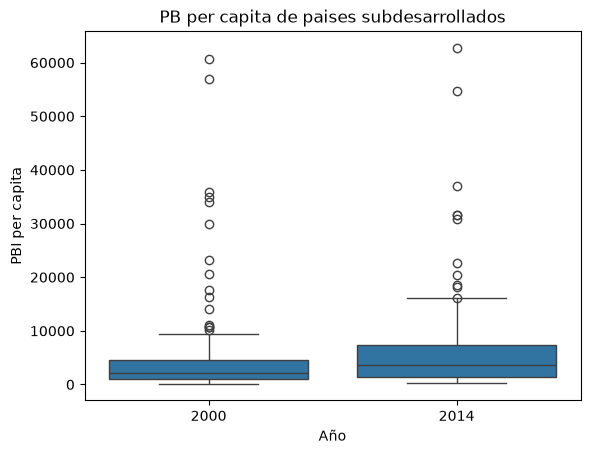

In [58]:
datos_box = subdesarrollados[['GDP_per_capita_2000', 'GDP_per_capita_2014']].melt(var_name='Year', value_name='Infant_deaths')
sns.boxplot(
    x='Year',
    y='Infant_deaths',
    data=datos_box,
    notch=False
)

plt.title("PB per capita de paises subdesarrollados")
plt.xlabel("Año")
plt.ylabel("PBI per capita")
plt.xticks(
    ticks=[0, 1],
    labels=["2000", "2014"]
)

plt.show()

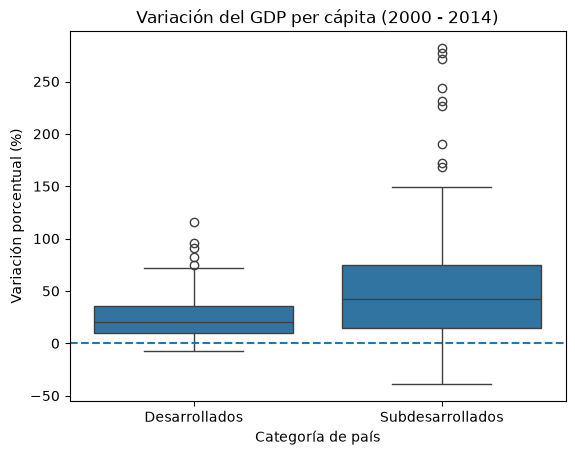

In [59]:
datos_box = pd.concat([
    desarrollados[['percentage_inc']].assign(Categoría='Desarrollados'),
    subdesarrollados[['percentage_inc']].assign(Categoría='Subdesarrollados')
])

sns.boxplot(
    x='Categoría',
    y='percentage_inc',
    data=datos_box
)

plt.title("Variación del GDP per cápita (2000 - 2014)")
plt.xlabel("Categoría de país")
plt.ylabel("Variación porcentual (%)")
plt.axhline(0, linestyle='--')

plt.show()

<h3>Normalidad

In [60]:
import scipy.stats as stats

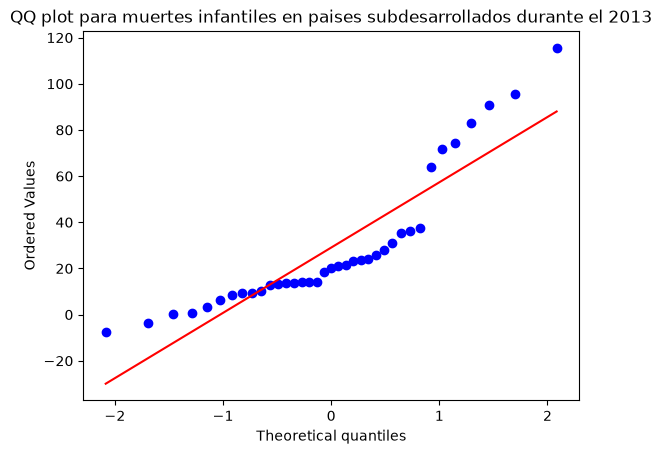

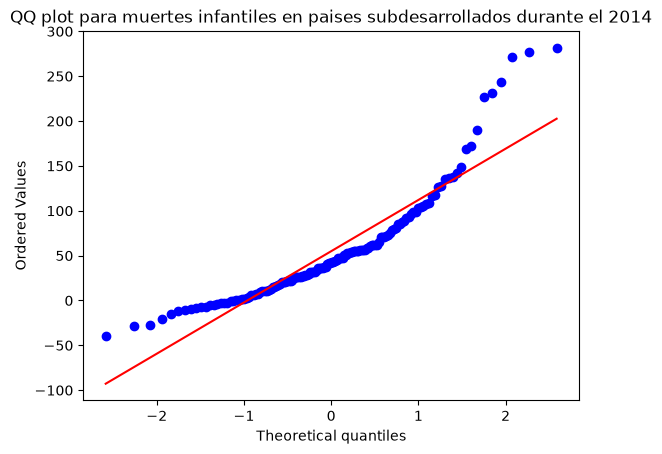

In [62]:
#QQ plot para paises desarrollados
stats.probplot(desarrollados['percentage_inc'], dist='norm', plot=plt)
plt.title('QQ plot para muertes infantiles en paises subdesarrollados durante el 2013')
plt.show()

stats.probplot(subdesarrollados['percentage_inc'], dist='norm', plot=plt)
plt.title('QQ plot para muertes infantiles en paises subdesarrollados durante el 2014')
plt.show()

In [64]:
from scipy.stats import shapiro

stat, p = shapiro(desarrollados['percentage_inc'])
print(f"Test de Shapiro-Wilk para muertes infantibles durante 2013: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para muertes infantibles durante 2013: Estadístico=0.825, p-valor=0.000


In [65]:
from scipy.stats import shapiro

stat, p = shapiro(subdesarrollados['percentage_inc'])
print(f"Test de Shapiro-Wilk para muertes infantibles durante 2013: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para muertes infantibles durante 2013: Estadístico=0.859, p-valor=0.000


<h3>Homocedasticidad

In [66]:
stat, p = stats.levene(desarrollados['percentage_inc'], subdesarrollados['percentage_inc'])
print(f"Test de Levene para percentage_expenditure: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para percentage_expenditure: Estadístico=7.939, p-valor=0.005


<h3>Kruskal Wallis

In [68]:
stat, p = stats.kruskal(desarrollados['percentage_inc'], subdesarrollados['percentage_inc'])
print(f"Test de Kruskal-Wallis para percentage expenditure: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el percentage expenditure entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el incremento porcentual entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para percentage expenditure: Estadístico=6.487, p-valor=0.011
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el incremento porcentual entre países desarrollados y en vías de desarrollo.


Finalmente, podemos concluir mediante mediante el test y el grafico que el incremento porcentual entre el 2000 y 2014 de PBI per capita de los paises subdesarrollados fue significativamente mayor que el de los paises desarrollados

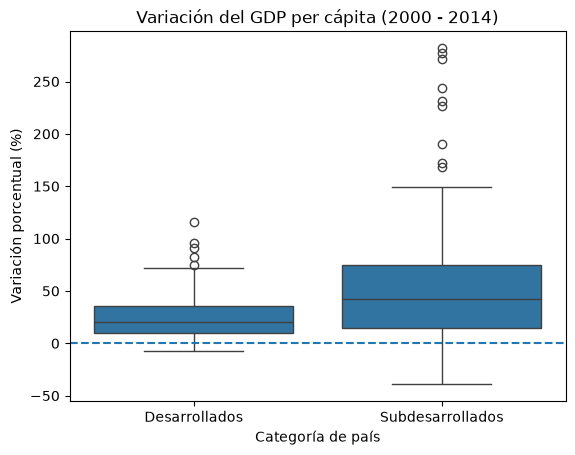